In [6]:
import numpy as np
import PKA_Sleep as PKA
from PKA_Sleep import Graphing_Utils as graph
import os
import pandas as pd
import importlib
import matplotlib.pyplot as plt
graph.make_bigandbold()
import glob
from scipy.signal import savgol_filter
from matplotlib.patches import Rectangle
from scipy.stats import wilcoxon

In [18]:
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 200
experimental_sensor = 'FLIM-mAKAR'
sleep_states = True
microarousals = True
seperate_acqs = False
emp_lifetime = False
gather_timestamps = False
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'
baseline_only = True
experiment_names = ['ltFLiPAKARmemEEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0010',
                    'dgFLiPmemAKAREEGEMG0003',
                    'dgFLiPmemAKAREEGEMG0008',
                    'ltFLiPAKARmemEEGEMG0036',
                    'ltFLiPAKARmemEEGEMG0043',
                    'kgFLiPAKAREEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0055',
                    'ltFLiPAKARmemEEGEMG0068',
                    'ltFLiPAKARmemEEGEMG0072',
                    'ltFLiPAKARmemEEGEMG0085',
                    'ltFLiPAKARmemEEGEMG0090-1',
                    'ltFLiPAKARmemEEGEMG0094',
                    'ltFLiPAKARmemEEGEMG0097-1',
                    'ltFLiPAKARmemEEGEMG0098-1',
                    'ltFLiPAKARmemEEGEMG0099-1',
                    'ltFLiPAKARmemEEGEMG0099-2',
                    'ltFLiPAKARmemEEGEMG0100-1',
                    'ltFLiPAKARmemEEGEMG0101-1',
                    'ltFLiPAKARmemEEGEMG0102-1',
                    'ltFLiPAKARmemEEGEMG0103-1']
mouse_names = ['3825',
                '3825',
                '3825',
                '3825',
                '4346-t5-7',
                '4346-t5-7',
                '4507',
                '4502',
                '4507',
                '4610',
                '4713',
                '4769',
                '4775',
                '5782',
                '5007',
                '5075',
                '5075',
                '5078',
                '5046',
                '5047',
                '5076']
raw_datadirs = [os.path.join(parent_data_directory, e) for e in experiment_names]
df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in experiment_names]]
excluded_acqs = PKA.choose_excluded_acqs(raw_datadirs, first_acqs = 3, specific_acqs = False, 
                                              pull_baseline = True, baseline_idxs = baseline_idxs)
   
FLP_classes_dict = PKA.build_classes(experiment_names, mouse_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                      exclude_acqs = excluded_acqs)

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_14283/1934148518.py:57: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values))


You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this experiment.
You are excluding the first 3 acquisitions of this expe

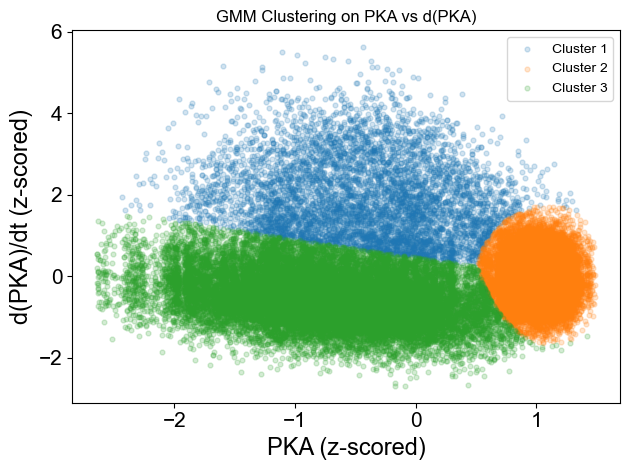

In [15]:
#Plot example trace
b = 'ltFLiPAKARmemEEGEMG0072'
FLP_exp = FLP_classes_dict['Experiment Classes'][FLP_classes_dict['Experiment Names'].index(b)]
baseline_fns = glob.glob(os.path.join(FLP_exp.rawdatdir,'par_variability', 'pars_baseline_*.npy'))
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_3/'
LFT_filt = savgol_filter(FLP_exp.Lifetime, 11, 2)
par_df = pd.DataFrame()
for i, f in enumerate(baseline_fns):
    baseline_pars = np.load(f, allow_pickle = True).item()
    par_keys = list(baseline_pars.keys())
    if 'Fit Range' in par_keys:
        par_keys.remove('Fit Range')
    for k in par_keys:
        par_df.loc[i, k] = baseline_pars[k]
par_df['Rising Tau'] = par_df.apply(lambda row: row['B1'] if row['S1'] > row['S2'] 
                                             else row['B2'], axis=1)
par_df['Rising Asymptote'] = par_df.apply(lambda row: row['S1'] if row['S1'] > row['S2'] 
                                                   else row['S2'], axis=1)
par_df['Falling Tau'] = par_df.apply(lambda row: row['B2'] if row['S1'] > row['S2'] 
                                              else row['B1'], axis=1)
par_df['Falling Asymptote'] = par_df.apply(lambda row: row['S2'] if row['S1'] > row['S2'] 
                                                    else row['S1'], axis=1)
fitS, fitState, fitError, BIC_ar = PKA.two_model_fit(LFT_filt, 
                                                 40, 1-1/np.nanmedian(par_df['Rising Tau']), np.nanmedian(par_df['Rising Asymptote']), 
                                                     1-1/np.nanmedian(par_df['Falling Tau']), np.nanmedian(par_df['Falling Asymptote']), 
                                                     plotflag=0)
(fig, ax),labels = PKA.gmm_cluster_pka(FLP_exp.Lifetime, win=40, num_clusters=3, reg_covar=1e-12,
                    max_iter=1000, replicates=5, plotflag=1, ax=None,
                    random_state=10)
fitState[labels==2] = 0

/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_14283/2009860119.py:18: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  r = Rectangle([FLP_exp.Time[i[0]], y_lims[0]], width = w, height = y_lims[-1]-y_lims[0], color = '#6a79f7', alpha = 1,
/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_14283/2009860119.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  r = Rectangle([FLP_exp.Time[i[0]], y_lims[0]], width = w, height = y_lims[-1]-y_lims[0], color = '#f9bc08', alpha = 1,
/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_14283/2009860119.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  r = Rectangle([FLP_exp.Time[i[0]], y_lims[0]], width = w, height = y_lims[-1]-y_lims[0], color = '#74a662', alpha = 1,
/var/folders/30/t1sfg_lj50j43rrvkwr7k7mw0000gn/T/ipykernel_14283/2009860119.py:33: UserWarning: set_tic

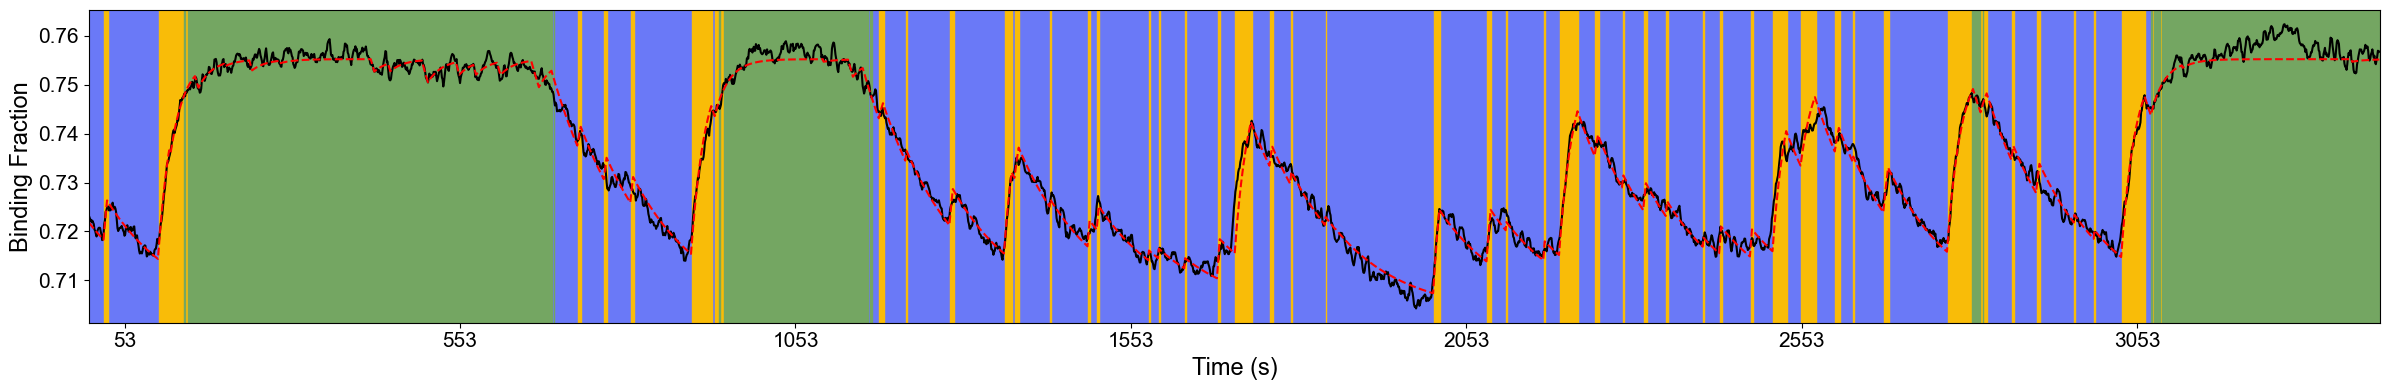

In [16]:
fig, ax = plt.subplots(figsize = [24, 4])
plotting_range_idx = [15600,18900]
rising_phase = PKA.find_continuous(fitState, [1])
rising_phase_cut = [i for i in rising_phase if (any(np.array(i) >= plotting_range_idx[0])) & (any(np.array(i) <= plotting_range_idx[1]))]

falling_phase = PKA.find_continuous(fitState, [-1])
falling_phase_cut = [i for i in falling_phase if (any(np.array(i) >= plotting_range_idx[0])) & (any(np.array(i) <= plotting_range_idx[1]))]

flat_phase = PKA.find_continuous(fitState, [0])
flat_phase_cut = [i for i in flat_phase if (any(np.array(i) >= plotting_range_idx[0])) & (any(np.array(i) <= plotting_range_idx[1]))]

ax.plot(FLP_exp.Time[plotting_range_idx[0]:plotting_range_idx[1]], LFT_filt[plotting_range_idx[0]:plotting_range_idx[1]], color = 'k')
ax.plot(FLP_exp.Time[plotting_range_idx[0]:plotting_range_idx[1]], fitS[plotting_range_idx[0]:plotting_range_idx[1]], 
        color = 'r', linestyle = '--')
y_lims = ax.get_ylim()
for i in falling_phase_cut:
    w = FLP_exp.Time[i[-1]+1]-FLP_exp.Time[i[0]]
    r = Rectangle([FLP_exp.Time[i[0]], y_lims[0]], width = w, height = y_lims[-1]-y_lims[0], color = '#6a79f7', alpha = 1, 
                  edgecolor = 'w')
    ax.add_patch(r)
for i in rising_phase_cut:
    w = FLP_exp.Time[i[-1]+1]-FLP_exp.Time[i[0]]
    r = Rectangle([FLP_exp.Time[i[0]], y_lims[0]], width = w, height = y_lims[-1]-y_lims[0], color = '#f9bc08', alpha = 1, 
                  edgecolor = 'w')
    ax.add_patch(r)

for i in flat_phase_cut:
    w = FLP_exp.Time[i[-1]+1]-FLP_exp.Time[i[0]]
    r = Rectangle([FLP_exp.Time[i[0]], y_lims[0]], width = w, height = y_lims[-1]-y_lims[0], color = '#74a662', alpha = 1, 
                  edgecolor = 'w')
    ax.add_patch(r)
ax.set_xlim([FLP_exp.Time[plotting_range_idx[0]], FLP_exp.Time[plotting_range_idx[1]]])
ax.set_xticklabels([f'{x-FLP_exp.Time[plotting_range_idx[0]]:.0f}' 
                     for x in ax.get_xticks()])
graph.label_axes(ax, x = 'Time (s)', y = 'Binding Fraction')
fig.tight_layout()
# fig.savefig(os.path.join(fig_savedir, 'Model_example_trace.ps'))

In [19]:
## - - - - - - - - - - - - - - - modeling fit scatter figure - - - - - -- - - - - -
FLP_classes_dict['par_files'] = [glob.glob(os.path.join(FLP_exp.rawdatdir,'par_variability', 'pars_baseline_*.npy')) 
                                  for FLP_exp in FLP_classes_dict['Experiment Classes']]
grouped_experiments = [[i for i in range(len(FLP_classes_dict['Animal Names'])) if str(FLP_classes_dict['Animal Names'][i]) == a] 
                       for a in np.unique(FLP_classes_dict['Animal Names'])]
fit_dict = {'Experiment Name': [], 'Animal Name': [], 'LFT_filt': [], 'Fit': [], 'Fit State': [], 'r2':[]}
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_3/'
for g in grouped_experiments:
    for ii in g:
        m = FLP_classes_dict['Animal Names'][ii]
        FLP_exp = FLP_classes_dict['Experiment Classes'][ii]
        fit_dict['Experiment Name'].append(FLP_classes_dict['Experiment Names'][ii])
        fit_dict['Animal Name'].append(m)
        print(FLP_classes_dict['Experiment Names'][ii]+'\n' + str(m))
        LFT_filt = savgol_filter(FLP_exp.Lifetime, 11, 2)
        par_df = pd.DataFrame()
        for i, f in enumerate(FLP_classes_dict['par_files'][ii]):
            # par_df.loc[i,'Experiment Name'] = b
            # par_df.loc[i,'Mouse ID'] = m
            baseline_pars = np.load(f, allow_pickle = True).item()
            par_keys = list(baseline_pars.keys())
            if 'Fit Range' in par_keys:
                par_keys.remove('Fit Range')
            for k in par_keys:
                par_df.loc[i, k] = baseline_pars[k]
        par_df['Rising Tau'] = par_df.apply(lambda row: row['B1'] if row['S1'] > row['S2'] 
                                                     else row['B2'], axis=1)
        par_df['Rising Asymptote'] = par_df.apply(lambda row: row['S1'] if row['S1'] > row['S2'] 
                                                           else row['S2'], axis=1)
        par_df['Falling Tau'] = par_df.apply(lambda row: row['B2'] if row['S1'] > row['S2'] 
                                                      else row['B1'], axis=1)
        par_df['Falling Asymptote'] = par_df.apply(lambda row: row['S2'] if row['S1'] > row['S2'] 
                                                            else row['S1'], axis=1)
        pars = {'B1': np.nanmedian(par_df['Rising Tau']), 
                'S1':np.nanmedian(par_df['Rising Asymptote']),
                'B2': np.nanmedian(par_df['Falling Tau']), 
                'S2':np.nanmedian(par_df['Falling Asymptote'])}
        LFT_filt, fitS, r2,fitState = PKA.apply_model(LFT_filt, pars, cluster = False, check_clusters = False, return_fitState = True, 
                                                      win = 40, return_full = True)
        fit_dict['LFT_filt'].append(LFT_filt)
        fit_dict['Fit'].append(fitS)
        fit_dict['Fit State'].append(fitState)
        fit_dict['r2'].append(r2)

ltFLiPAKARmemEEGEMG0009
3825
ltFLiPAKARmemEEGEMG0010
3825
dgFLiPmemAKAREEGEMG0003
3825
dgFLiPmemAKAREEGEMG0008
3825
ltFLiPAKARmemEEGEMG0036
4346-t5-7
ltFLiPAKARmemEEGEMG0043
4346-t5-7
ltFLiPAKARmemEEGEMG0055
4502
kgFLiPAKAREEGEMG0009
4507
ltFLiPAKARmemEEGEMG0068
4507
ltFLiPAKARmemEEGEMG0072
4610
ltFLiPAKARmemEEGEMG0085
4713
ltFLiPAKARmemEEGEMG0090-1
4769
ltFLiPAKARmemEEGEMG0094
4775
ltFLiPAKARmemEEGEMG0098-1
5007
ltFLiPAKARmemEEGEMG0101-1
5046
ltFLiPAKARmemEEGEMG0102-1
5047
ltFLiPAKARmemEEGEMG0099-1
5075
ltFLiPAKARmemEEGEMG0099-2
5075
ltFLiPAKARmemEEGEMG0103-1
5076
ltFLiPAKARmemEEGEMG0100-1
5078
ltFLiPAKARmemEEGEMG0097-1
5782


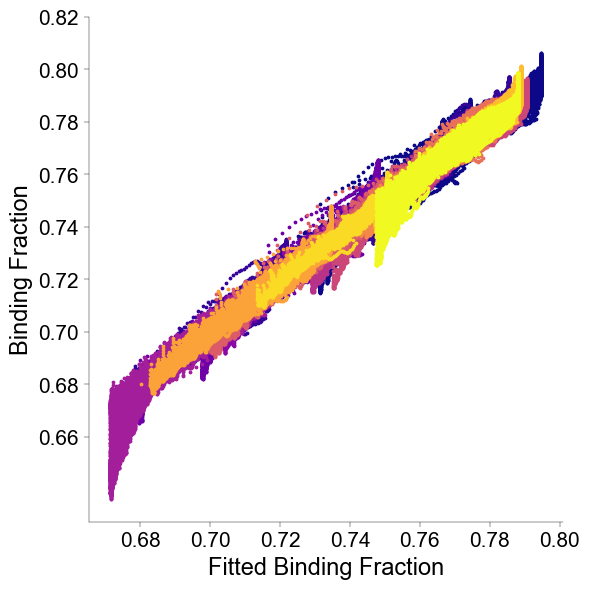

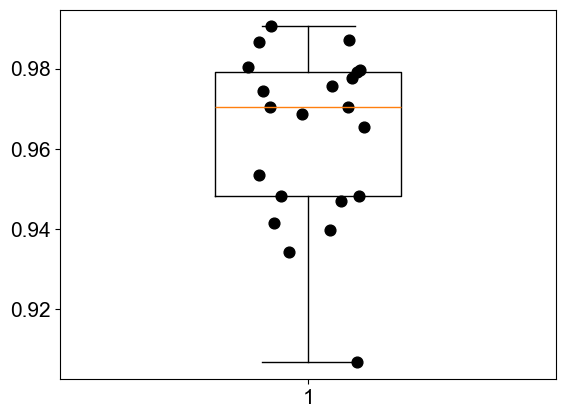

In [24]:
fig, ax = plt.subplots(figsize = [6,6])
color_list = graph.get_colormap(len(np.unique(FLP_classes_dict['Animal Names'])),cmap_name = 'plasma')
color_dict = dict(zip(np.unique(FLP_classes_dict['Animal Names']), color_list))

for i in range(len(fit_dict['Experiment Name'])):
    LFT_filt_ds = fit_dict['LFT_filt'][i]
    fitS_ds = fit_dict['Fit'][i]
    scatter = ax.scatter(fitS_ds[fitS_ds > 0], LFT_filt_ds[fitS_ds > 0], color = color_dict[str(fit_dict['Animal Name'][i])], s = 3, 
               alpha = 1, label = FLP_classes_dict['Animal Names'][i])
scatter.set_rasterized(True)
r2_fig, r2_ax = plt.subplots()
r2_ax.boxplot(fit_dict['r2'])
r2_ax.scatter(graph.get_jittered_x(1, len(fit_dict['r2']), width=0.05), fit_dict['r2'], 
              color = 'k', s = 60)
graph.label_axes(ax, x = 'Fitted Binding Fraction', y = 'Binding Fraction')
graph.thick_axes(fig, ax, width = 0.3)
r2_ax.set_xlim([0.8, 1.2])
ax.set_yticks(ax.get_xticks())
fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'fit_scatter.tiff'),  dpi=300, bbox_inches='tight')
r2_fig.savefig(os.path.join(fig_savedir, 'fit_boxfig.ps'))

In [3]:
exp_lin_fit_comp = np.load('/Volumes/yaochen/Active/Lizzie/FLP_data/exp_lin_fits.npy', allow_pickle = True).item()

In [4]:
lin_fits = [exp_lin_fit_comp[a]['Linear Fit']['bic'] for a in exp_lin_fit_comp.keys()]
exp_fits = [exp_lin_fit_comp[a]['Exponential Fit']['bic'] for a in exp_lin_fit_comp.keys()]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


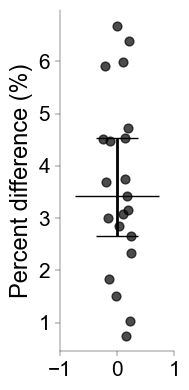

In [5]:
color_list = graph.get_colormap(len(exp_lin_fit_comp.keys()))
fig, ax = plt.subplots(figsize = [2,4])
graph.swarm_plot(fig, ax, [[((e-l)/e)*100 for l,e in zip(lin_fits, exp_fits)]], [0], ['k'], edgecolors=None, x_width=0.25, avg_type='median', percentiles=[25, 75], 
                 x_labels=None, ylabel=None, capsize=15, markersize=60, alpha=0.7, scatter_size=40, match_ebarcolor=False, 
                 legend_labels=None)
ax.set_xlim([-1,1])
graph.thick_axes(fig, ax, width = 0.3)
graph.label_axes(ax, y = 'Percent difference (%)')
fig.tight_layout()
fig.savefig('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_3/BIC_percdiff.png')
fig.savefig('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_3/BIC_percdiff.ps')

In [7]:
wilcoxon([((e-l)/e)*100 for l,e in zip(lin_fits, exp_fits)])

WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(9.5367431640625e-07))